In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Read the file with a different encoding
df = pd.read_csv('SeoulBikeData.csv', encoding='latin1')
 # View first few rows
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [184]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

 My data is generally clean with no missing values.
 The main challenge now is not cleaning, but converting data types (like 'Date') and analyzing distributions and correlations
to decide which features to include in the modeling.


In [185]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


The data looks generally clean with no missing values. The main focus now is on transforming the Date column, analyzing distributions (especially the skewed target), checking correlations, and deciding which features to include in the model.

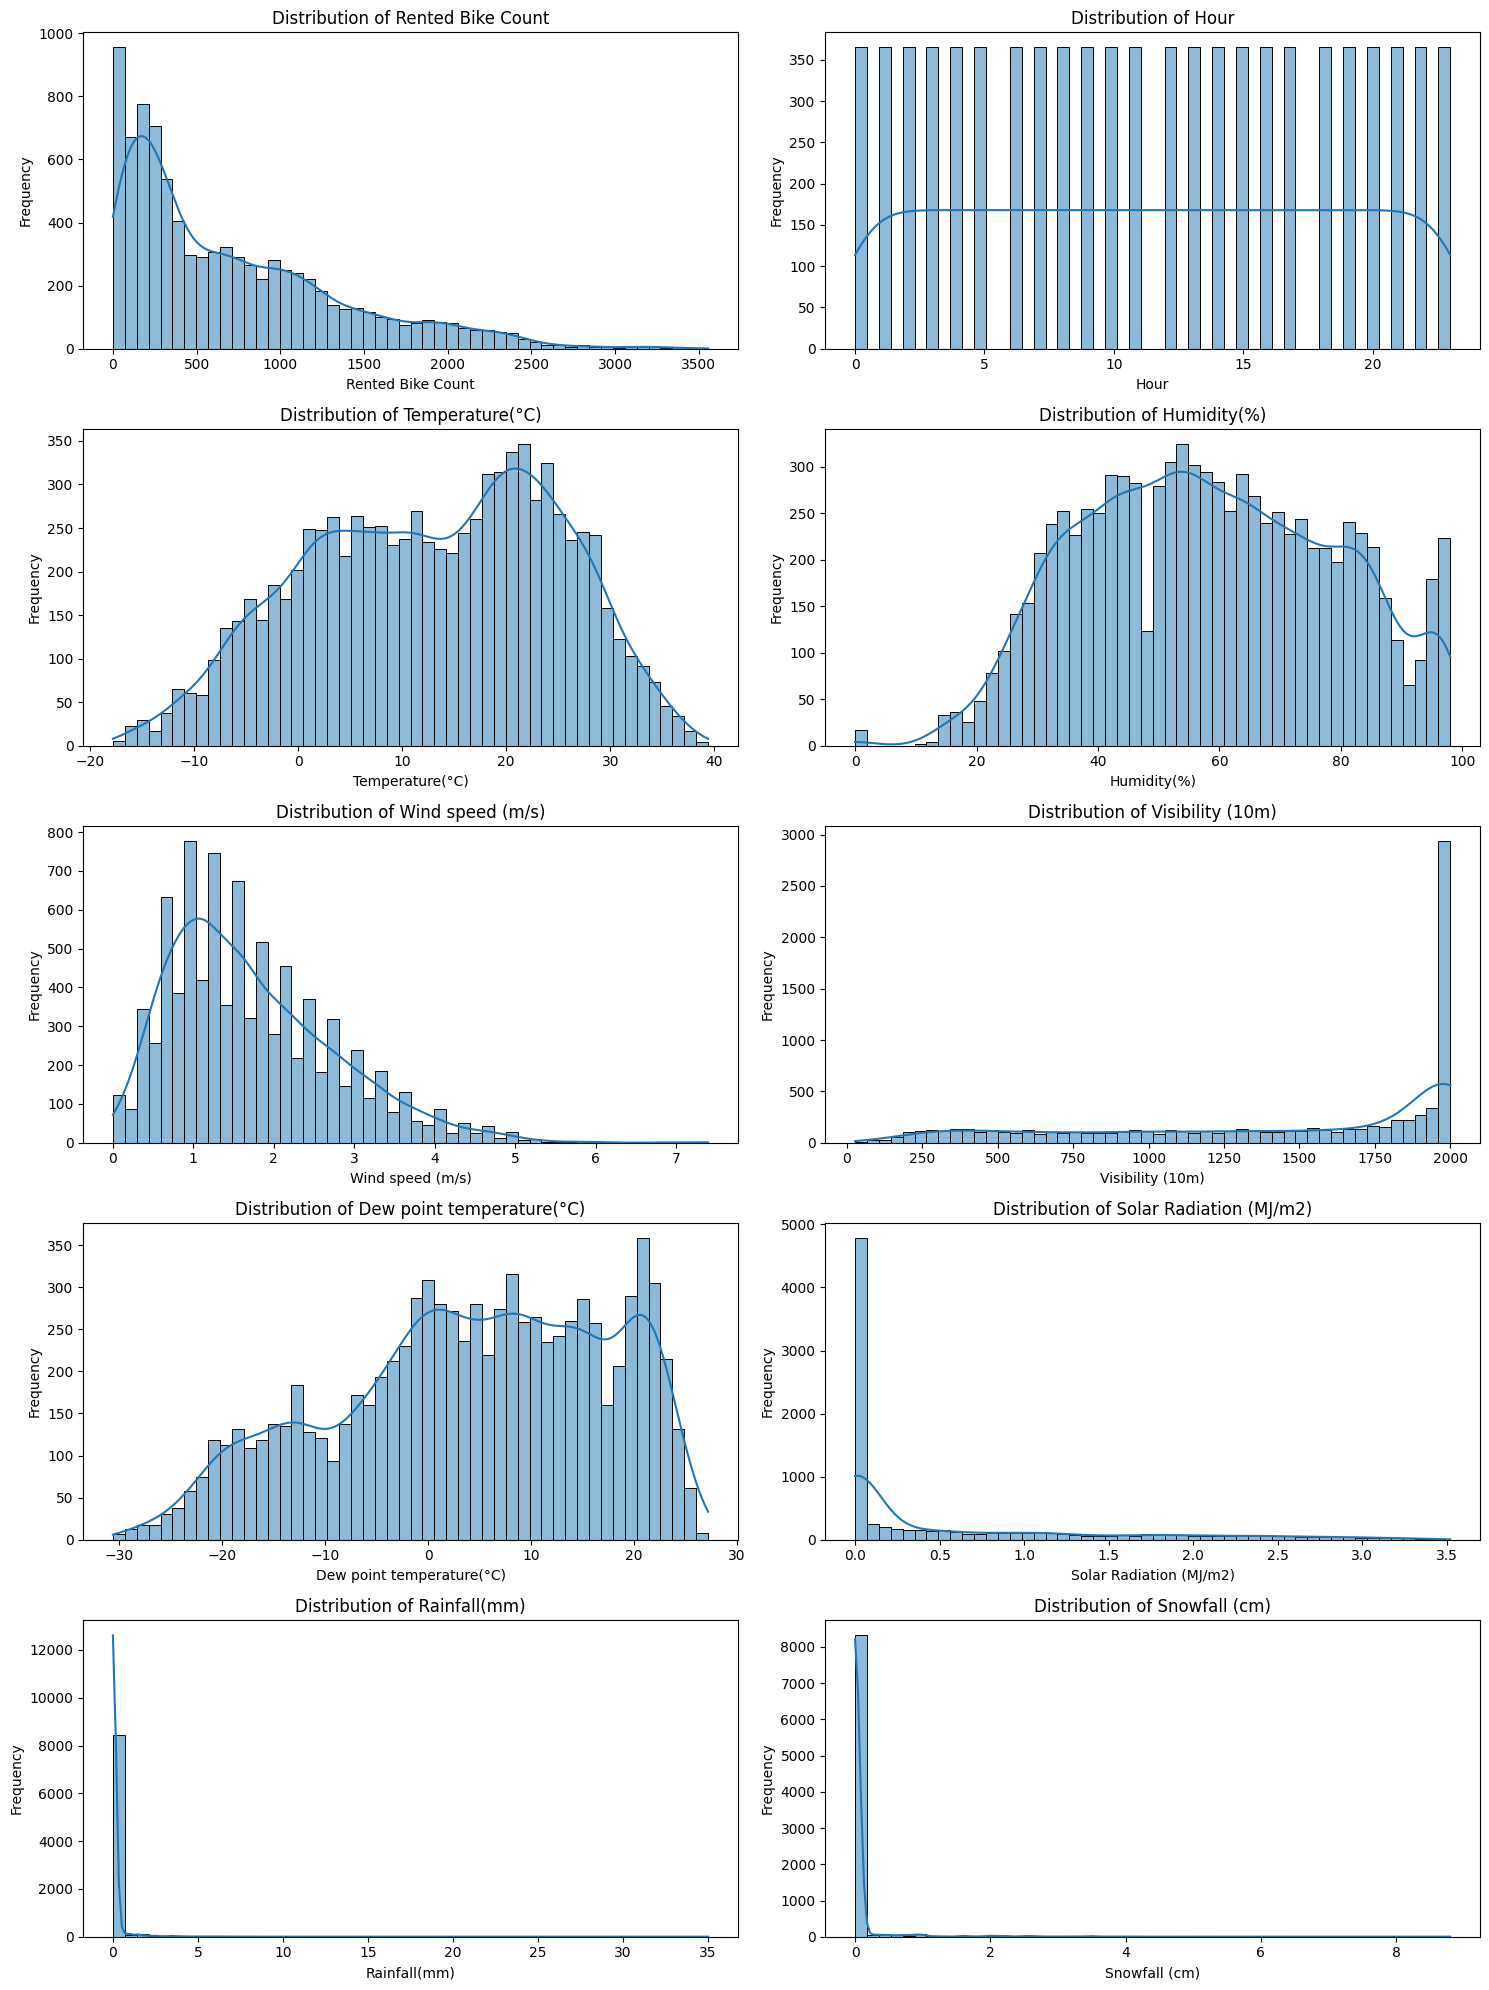

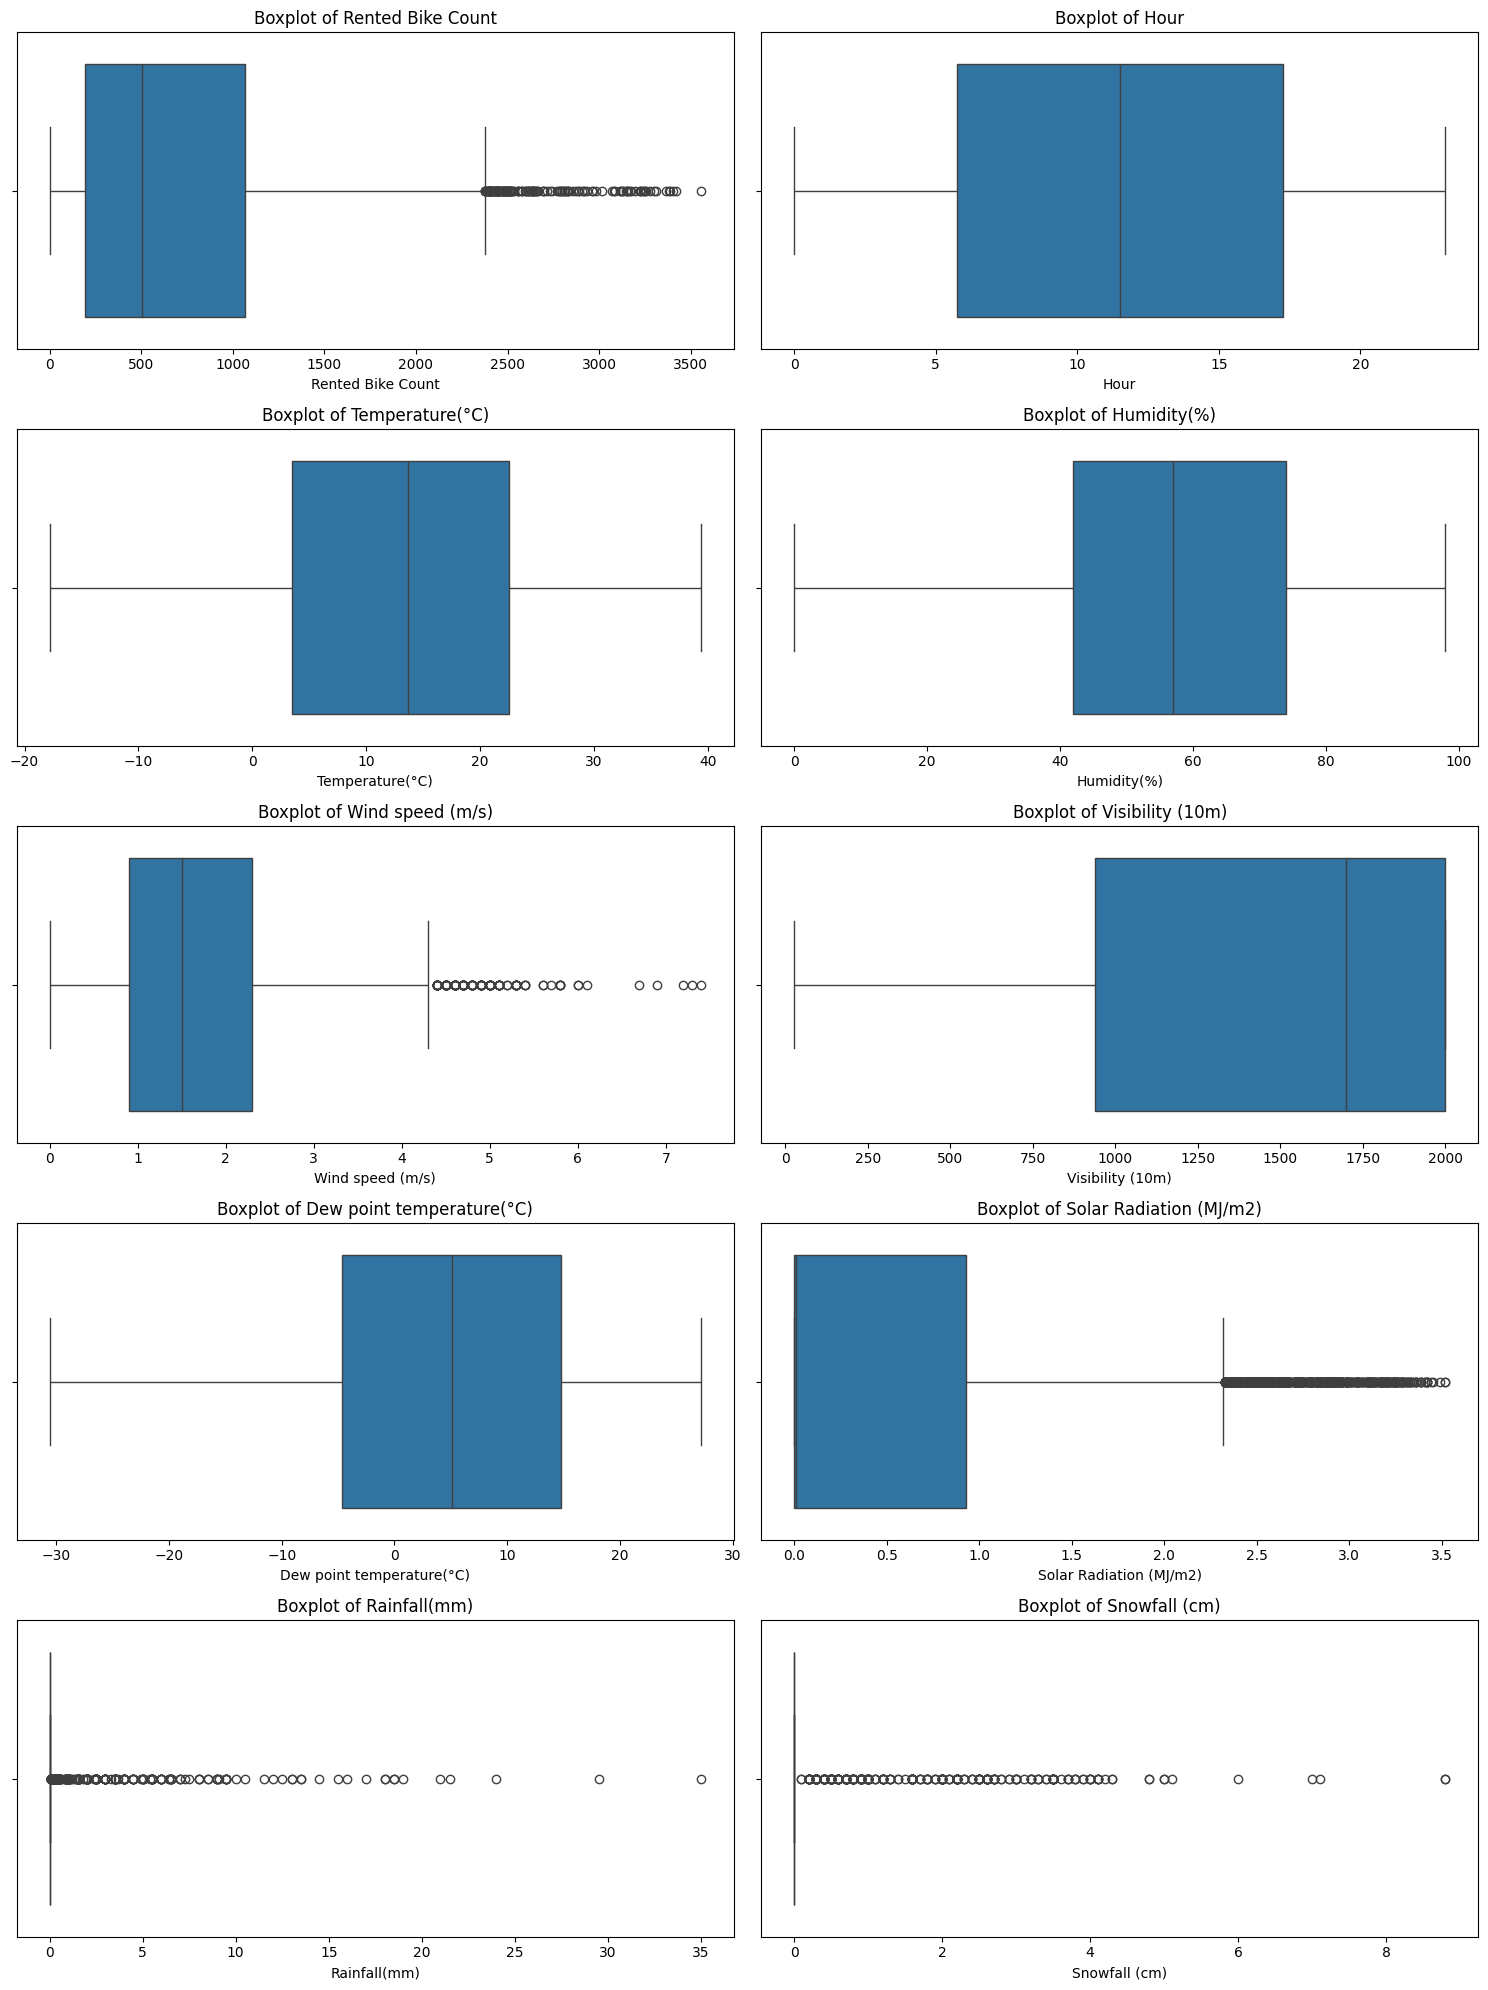

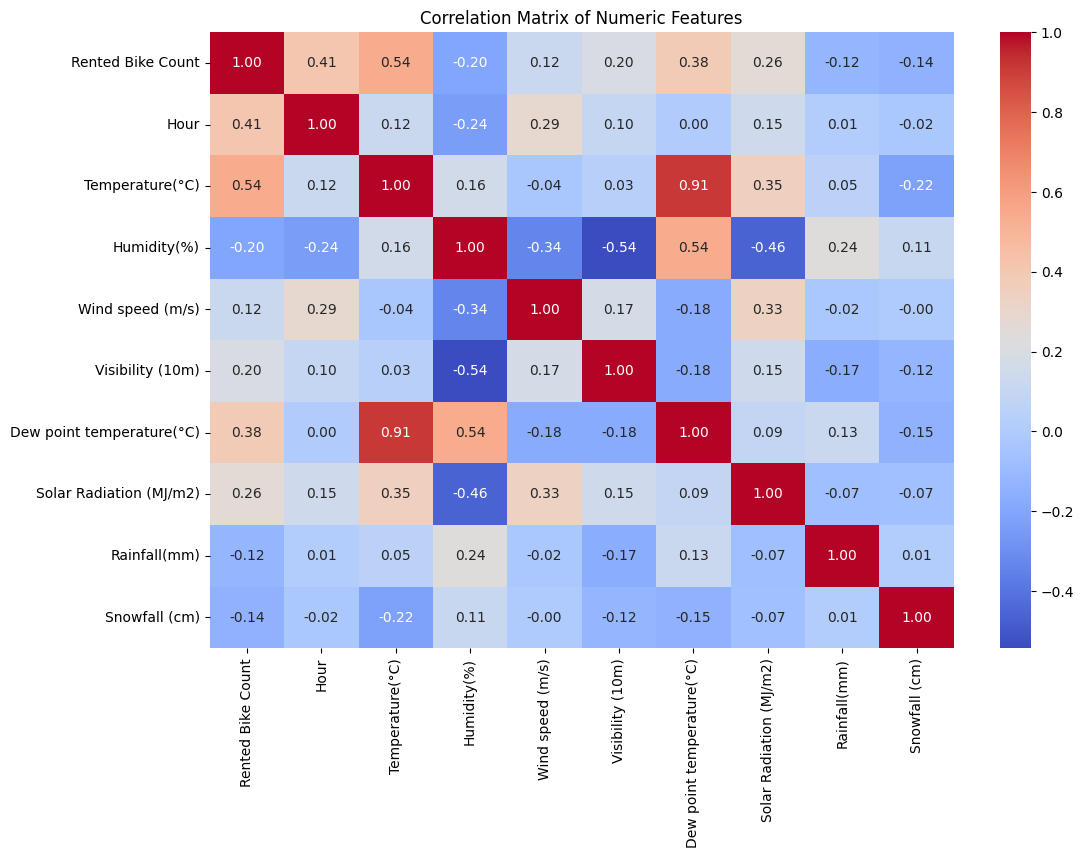

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data
df = pd.read_csv('SeoulBikeData.csv', encoding='latin1')

# Set the figure size
plt.figure(figsize=(15,20))

# List of numeric variables
numeric_cols = ['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
                'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
                'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

# Plot histogram for each numeric variable
for i, col in enumerate(numeric_cols):
    plt.subplot(5, 2, i+1)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Plot boxplot for each numeric variable to observe outliers
plt.figure(figsize=(15,20))
for i, col in enumerate(numeric_cols):
    plt.subplot(5, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Plot correlation matrix heatmap
plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()


In [187]:
# Loop through each column in the DataFrame
for col in df.columns:
    # Print the column name
    print(f"Value counts for column: {col}")

    # Count how many times each unique value appears in the column
    print(df[col].value_counts())

    # Print a separator line for better readability between columns
    print("\n" + "="*40 + "\n")


Value counts for column: Date
Date
30/11/2018    24
01/12/2017    24
02/12/2017    24
03/12/2017    24
04/12/2017    24
              ..
18/12/2017    24
17/12/2017    24
16/12/2017    24
15/12/2017    24
14/12/2017    24
Name: count, Length: 365, dtype: int64


Value counts for column: Rented Bike Count
Rented Bike Count
0       295
122      19
223      19
262      19
165      18
       ... 
1907      1
1228      1
1316      1
2632      1
1961      1
Name: count, Length: 2166, dtype: int64


Value counts for column: Hour
Hour
0     365
1     365
2     365
3     365
4     365
5     365
6     365
7     365
8     365
9     365
10    365
11    365
12    365
13    365
14    365
15    365
16    365
17    365
18    365
19    365
20    365
21    365
22    365
23    365
Name: count, dtype: int64


Value counts for column: Temperature(°C)
Temperature(°C)
20.5    40
19.1    40
23.4    39
20.7    38
7.6     38
        ..
37.0     1
37.6     1
35.9     1
36.0     1
36.9     1
Name: count, Length: 

**Important Observations from the Results:**

Date: Contains 365 unique values, each repeated 24 times (representing each
hour of the day).

Cannot be used directly as a numeric feature, but important for extracting features like season, month, or day of the week later.

Rented Bike Count: Very wide distribution (2166 unique values).

Consider applying a log transformation later to reduce skewness.

Watch out for potential outliers.

Hour: Perfectly balanced distribution (each hour represented equally).

This is good as it prevents temporal bias in the model.

Solar Radiation, Rainfall, Snowfall: Many zero values (e.g., about half of solar radiation values are zero).

These features may be irrelevant at night or highly seasonal, which should be considered during analysis or modeling.

Holiday and Functioning Day: Imbalanced classes (most days are not holidays, and most days are functioning).

Be cautious of potential model bias due to this imbalance.

Visibility: The value 2000 appears very frequently.

This might be a maximum measurement limit or a default sensor value.

 **Key Points to Consider Before Proceeding: **

Are there any irrelevant or duplicate columns that can be dropped to simplify the model?

Do any columns need data type conversion? (e.g., converting the Date column from object to datetime)

Are there columns with outliers or skewed distributions that might affect model performance?

Are there categorical variables like Seasons and Holiday that require encoding into numeric features before modeling?

In [188]:
# Display a sorted table showing the count of missing values in each column
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

Series([], dtype: int64)


In [189]:
# Change 'Date' column to datetime format with day-first format using the assign method
df = df.assign(Date=pd.to_datetime(df['Date'], dayfirst=True))

# Show the first 5 rows of the updated 'Date' column
print(df['Date'].head())


0   2017-12-01
1   2017-12-01
2   2017-12-01
3   2017-12-01
4   2017-12-01
Name: Date, dtype: datetime64[ns]


In [190]:
# Calculate the correlation matrix for numeric columns in the DataFrame df
correlation_matrix = df.corr(numeric_only=True)

# Print the correlation matrix
print(correlation_matrix)


                           Rented Bike Count      Hour  Temperature(°C)  \
Rented Bike Count                   1.000000  0.410257         0.538558   
Hour                                0.410257  1.000000         0.124114   
Temperature(°C)                     0.538558  0.124114         1.000000   
Humidity(%)                        -0.199780 -0.241644         0.159371   
Wind speed (m/s)                    0.121108  0.285197        -0.036252   
Visibility (10m)                    0.199280  0.098753         0.034794   
Dew point temperature(°C)           0.379788  0.003054         0.912798   
Solar Radiation (MJ/m2)             0.261837  0.145131         0.353505   
Rainfall(mm)                       -0.123074  0.008715         0.050282   
Snowfall (cm)                      -0.141804 -0.021516        -0.218405   

                           Humidity(%)  Wind speed (m/s)  Visibility (10m)  \
Rented Bike Count            -0.199780          0.121108          0.199280   
Hour              

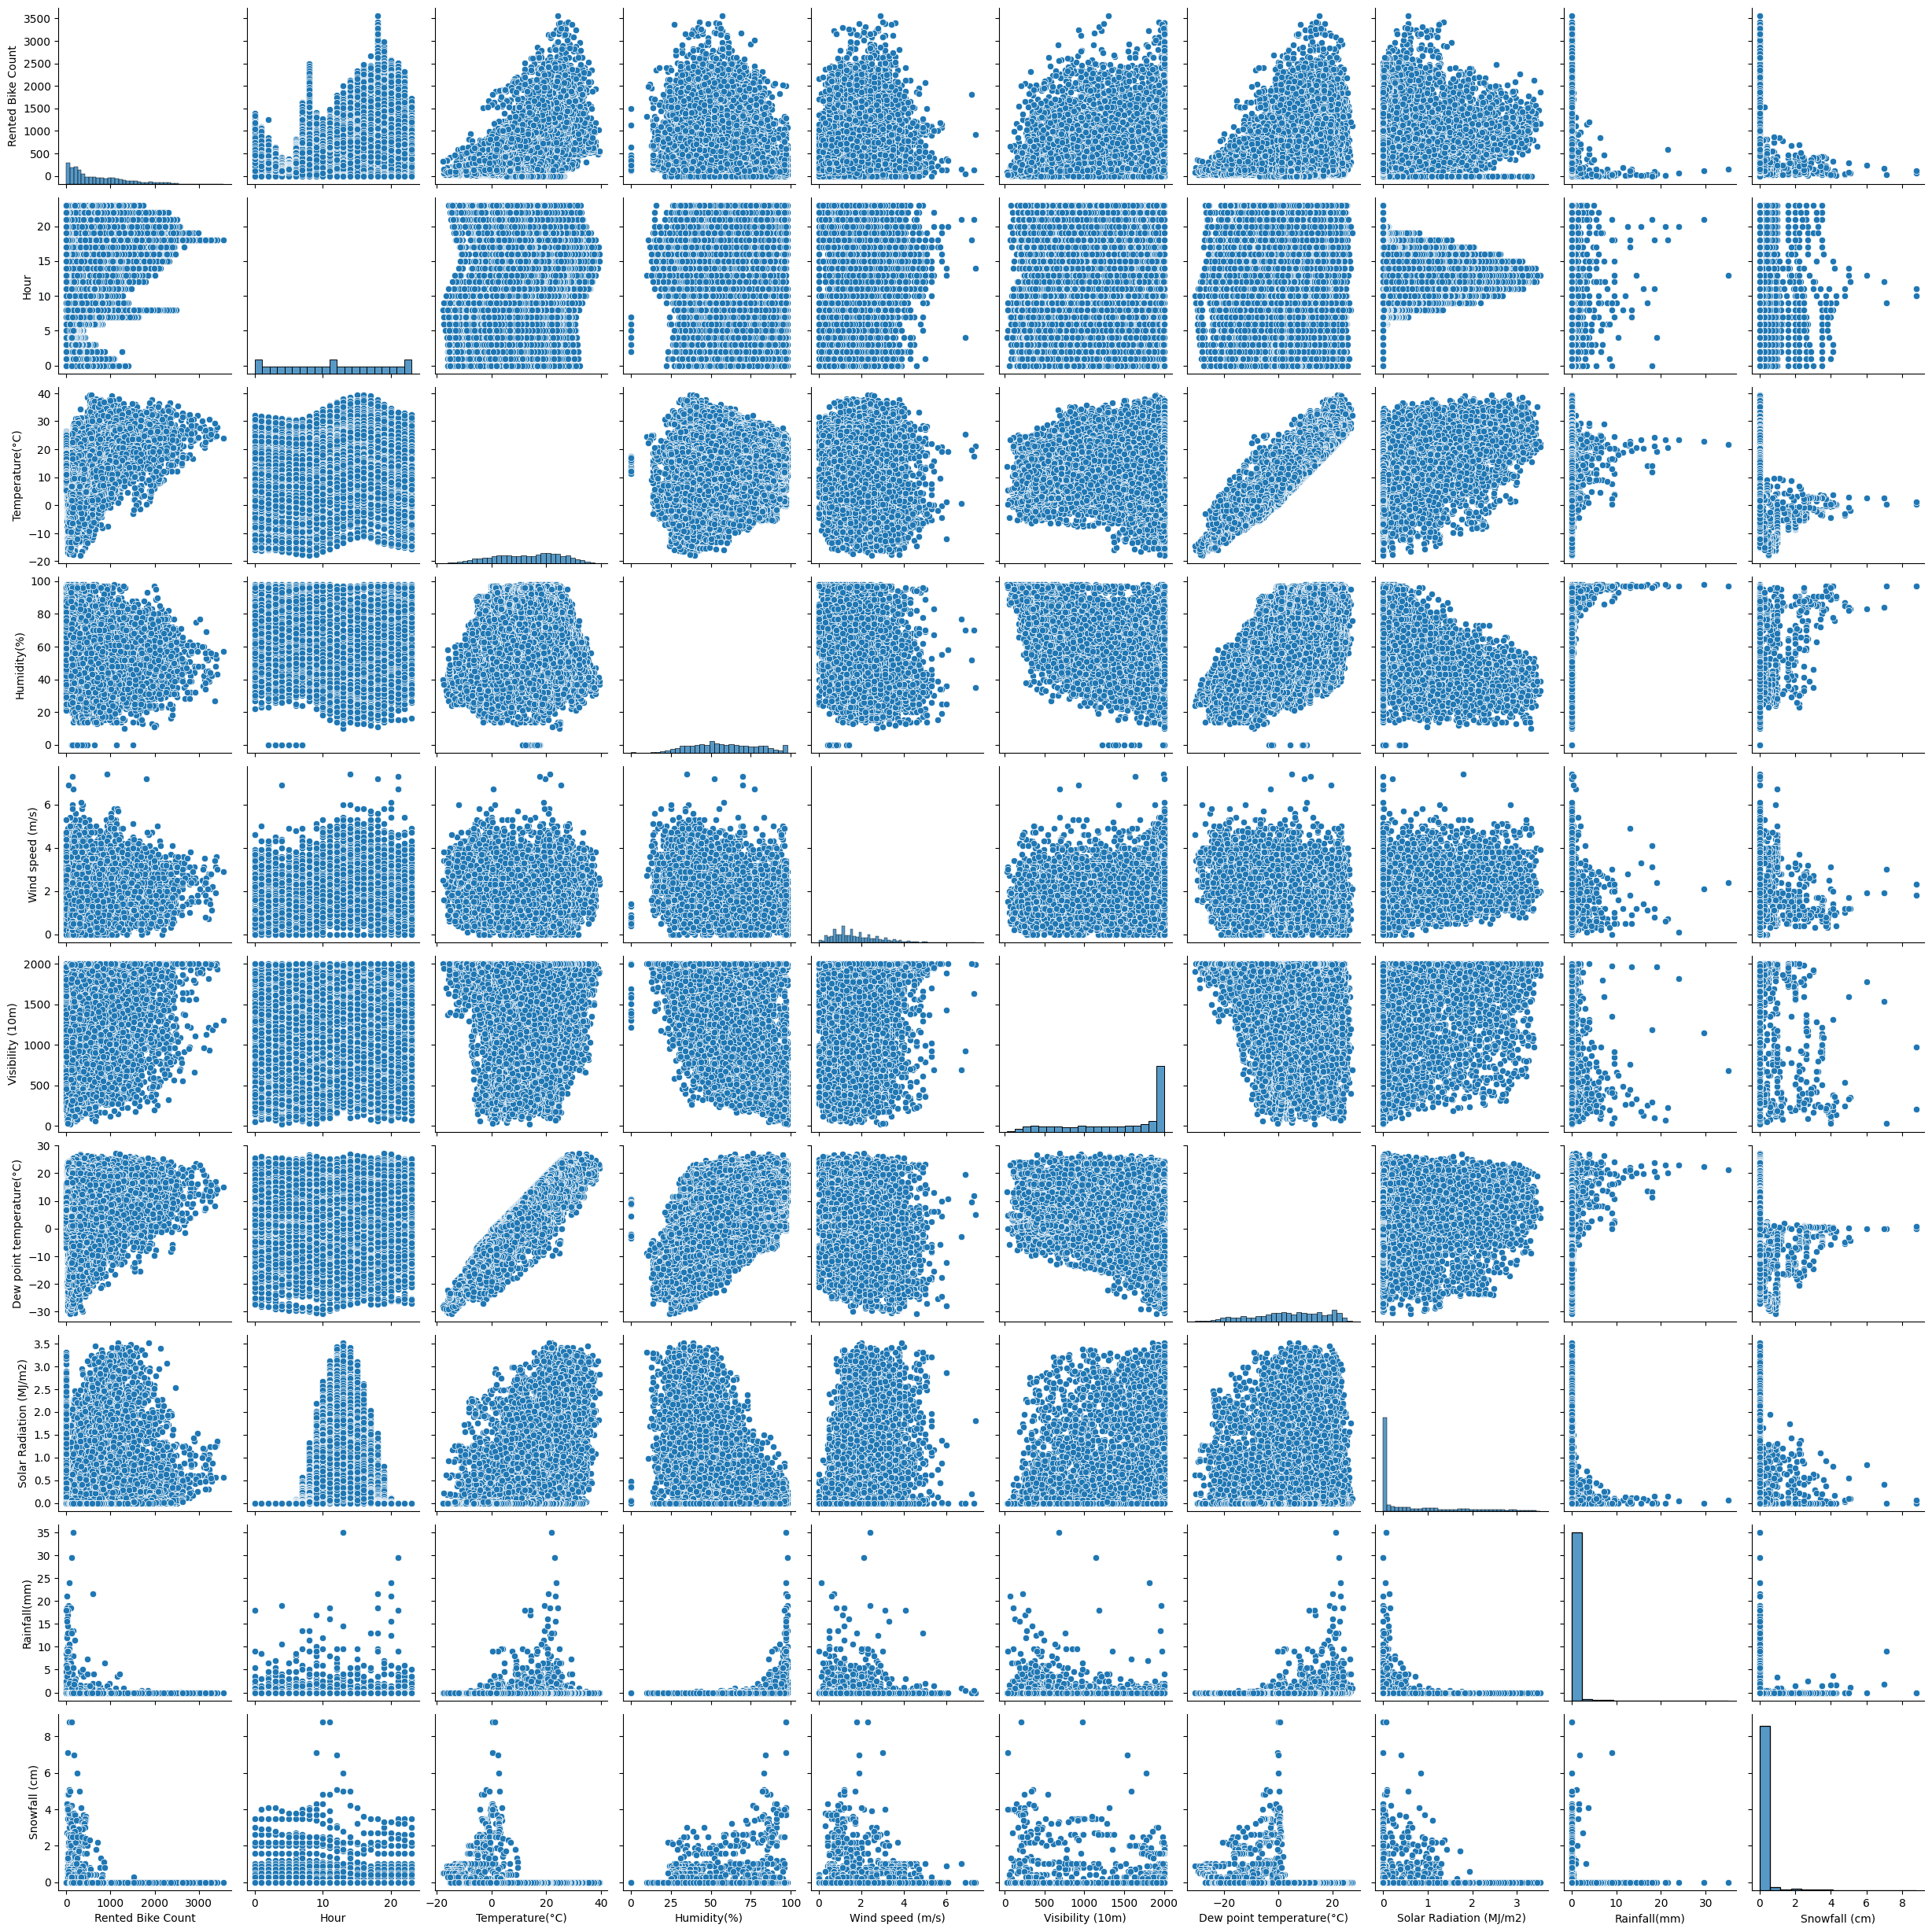

In [191]:
sns.pairplot(df)

Important Observations from the Correlation and Pairplot Analysis

Hour: Shows a moderate positive correlation (0.41) with Rented Bike Count. Bike rentals peak during morning and evening rush hours, indicating a clear daily temporal pattern. This variable is important for capturing time-of-day effects in the model.

Temperature (°C): Has a moderate positive correlation (0.54) with Rented Bike Count. Warmer temperatures tend to increase bike rentals, especially during mild weather, making it one of the strongest predictors among weather-related variables.

Humidity (%): Exhibits a weak negative correlation (-0.20) with bike rentals. High humidity slightly reduces rentals, but the effect is limited, suggesting that humidity alone is not a strong driver.

Dew Point Temperature (°C): Shows a moderate positive correlation (0.38). Since it is closely related to air temperature, it influences rentals similarly. Multicollinearity with temperature should be considered if both variables are used in the model.

Wind Speed (m/s): Correlation is weak (0.12). Wind has minimal influence on bike rentals, so its predictive value may be limited.

Visibility (10m): Weak positive correlation (0.20). Lower visibility may indicate poor weather conditions (fog or rain), slightly reducing rentals.

Solar Radiation (MJ/m²): Weak-to-moderate positive correlation (0.26). Higher solar radiation encourages rentals, but many zero values (nighttime or cloudy days) reduce its overall impact.

Rainfall (mm) and Snowfall (cm): Weak negative correlations (-0.12 and -0.14, respectively). Precipitation decreases bike rentals, but most days have no rainfall or snow, limiting the overall effect.

Key Takeaways:

The most influential variables for bike rentals are Temperature, Hour, and Dew Point Temperature.

Weather variables like Humidity, Wind, Rainfall, Snowfall, and Visibility have weaker effects but may still contribute slightly to model predictions.

Some variables are correlated with each other (e.g., Temperature and Dew Point), which could lead to multicollinearity if included together.

There is a clear daily temporal pattern, with predictable peaks and lows, which should be considered for feature engineering.

In [192]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Convert 'Date' column to datetime (day first)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# 2. Convert categorical columns to numeric codes using cat.codes
# because ML models need numeric inputs, not text
categorical_cols = ['Seasons', 'Holiday', 'Functioning Day']
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

# 3. Keep the 'Date' column separately because datetime can't be scaled directly
date_col = df['Date']

# 4. Drop the 'Date' column to keep only numeric columns for scaling
df_numeric = df.drop(columns=['Date'])

# 5. Create a MinMaxScaler object to scale numeric data to the range [0, 1]
scaler = MinMaxScaler()

# 6. Apply MinMaxScaler only on the numeric columns
df_scaled_numeric = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

# 7. Concatenate the original 'Date' column back to the scaled numeric dataframe
df_scaled = pd.concat([date_col.reset_index(drop=True), df_scaled_numeric.reset_index(drop=True)], axis=1)

# 8.Show first 5 rows of the new scaled dataframe
df_scaled.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,0.071429,0.000000,0.220280,0.377551,0.297297,1.0,0.224913,0.0,0.0,0.0,1.0,1.0,1.0
1,2017-12-01,0.057368,0.043478,0.215035,0.387755,0.108108,1.0,0.224913,0.0,0.0,0.0,1.0,1.0,1.0
2,2017-12-01,0.048650,0.086957,0.206294,0.397959,0.135135,1.0,0.223183,0.0,0.0,0.0,1.0,1.0,1.0
3,2017-12-01,0.030090,0.130435,0.202797,0.408163,0.121622,1.0,0.224913,0.0,0.0,0.0,1.0,1.0,1.0
4,2017-12-01,0.021935,0.173913,0.206294,0.367347,0.310811,1.0,0.207612,0.0,0.0,0.0,1.0,1.0,1.0


/tmp/ipython-input-1246146172.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TempCategory', y='Rented Bike Count', data=df, palette='Set2')


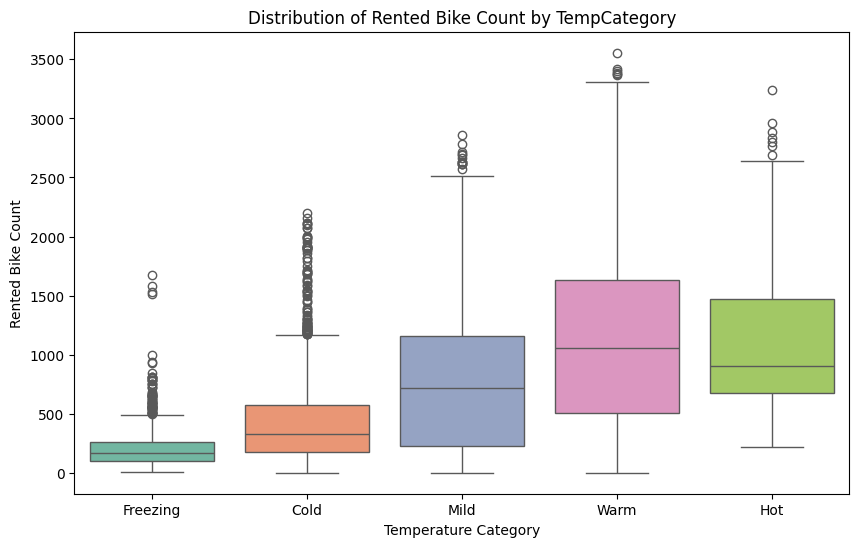

/tmp/ipython-input-1246146172.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TimeOfDay', y='Rented Bike Count', data=df, palette='Set3')


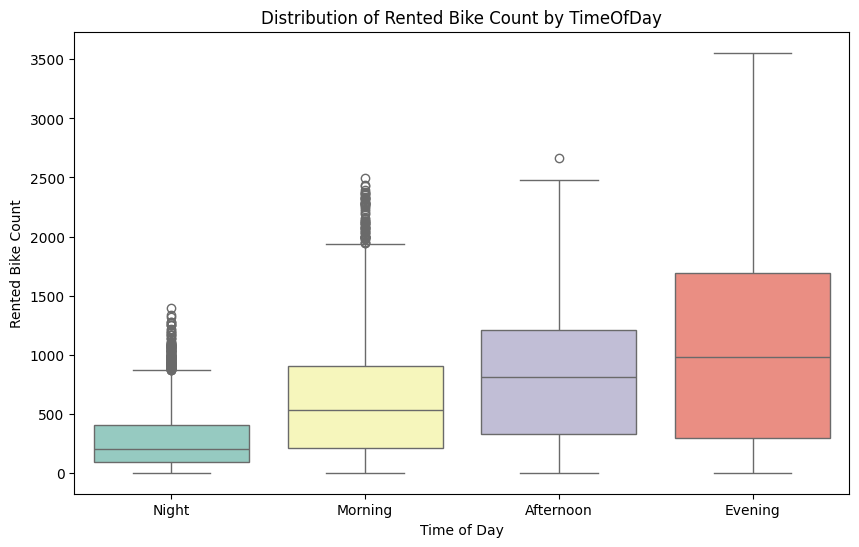

        Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
0 2017-12-01                254     0             -5.2           37   
1 2017-12-01                204     1             -5.5           38   
2 2017-12-01                173     2             -6.0           39   
3 2017-12-01                107     3             -6.2           40   
4 2017-12-01                 78     4             -6.0           36   

   Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
0               2.2              2000                      -17.6   
1               0.8              2000                      -17.6   
2               1.0              2000                      -17.7   
3               0.9              2000                      -17.6   
4               2.3              2000                      -18.6   

   Solar Radiation (MJ/m2)  Rainfall(mm)  ...  DayOfWeek  Weekend  TimeOfDay  \
0                      0.0           0.0  ...          4        0      Night   
1   

In [193]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- 1. Convert Date Column ----------------
df['Date'] = pd.to_datetime(df['Date'])

# ---------------- 2. Temporal Features ----------------
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['TimeOfDay'] = pd.cut(df['Hour'], bins=[-1,5,11,17,23], labels=['Night','Morning','Afternoon','Evening'])

# ---------------- 3. Weather Features ----------------
def temp_category(temp):
    if temp <= 0:
        return 'Freezing'
    elif temp <= 10:
        return 'Cold'
    elif temp <= 20:
        return 'Mild'
    elif temp <= 30:
        return 'Warm'
    else:
        return 'Hot'

df['TempCategory'] = df['Temperature(°C)'].apply(temp_category)

def weather_condition(row):
    if row['Rainfall(mm)'] > 0 and row['Solar Radiation (MJ/m2)'] < 1:
        return 'Rainy'
    elif row['Solar Radiation (MJ/m2)'] > 3:
        return 'Sunny'
    else:
        return 'Freezing'

df['WeatherCondition'] = df.apply(weather_condition, axis=1)

# ---------------- 3a. Plot Figure 3: Distribution by TempCategory and TimeOfDay ----------------
# Distribution by TempCategory
plt.figure(figsize=(10,6))
sns.boxplot(x='TempCategory', y='Rented Bike Count', data=df, palette='Set2')
plt.title('Distribution of Rented Bike Count by TempCategory')
plt.xlabel('Temperature Category')
plt.ylabel('Rented Bike Count')
plt.show()

# Distribution by TimeOfDay
plt.figure(figsize=(10,6))
sns.boxplot(x='TimeOfDay', y='Rented Bike Count', data=df, palette='Set3')
plt.title('Distribution of Rented Bike Count by TimeOfDay')
plt.xlabel('Time of Day')
plt.ylabel('Rented Bike Count')
plt.show()

# ---------------- 4. Lag Features ----------------
df['Lag_1h'] = df['Rented Bike Count'].shift(1).bfill()
df['Lag_24h'] = df['Rented Bike Count'].shift(24).bfill()

# ---------------- 5. Interaction Features ----------------
df['Temp_x_Hour'] = df['Temperature(°C)'] * df['Hour']

# Convert Seasons to numeric if categorical
if df['Seasons'].dtype.name == 'category':
    df['Temp_x_Season'] = df['Temperature(°C)'] * df['Seasons'].cat.codes
else:
    df['Temp_x_Season'] = df['Temperature(°C)'] * df['Seasons']

df['Hour_x_Weekend'] = df['Hour'] * df['Weekend']

# ---------------- 6. Final Check ----------------
print(df.head())
print(df.info())


I enriched the dataset with multiple engineered features to improve prediction. I converted the Date column to datetime and extracted the day of the week (DayOfWeek) and a weekend indicator (Weekend). I divided the hours into time-of-day periods (TimeOfDay) to capture daily patterns in bike rentals.

I categorized Temperature (TempCategory) as Cold, Mild, or Hot, and inferred WeatherCondition from rainfall, snowfall, and solar radiation to give context on environmental effects. I created lag features (Lag_1h and Lag_24h) to capture temporal dependencies, and interaction features (Temp_x_Season and Hour_x_Weekend) to model combined effects of multiple variables.

Finally, I encoded categorical features numerically to make the dataset ready for prediction. The resulting dataset, now with 23 columns, combines original and engineered features, giving richer patterns for predictive modeling.

In [194]:
import pandas as pd

# ---- 1. Encode categorical features as numeric ----
categorical_cols = ['TimeOfDay', 'TempCategory', 'WeatherCondition']
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

# ---- 2. List of engineered numeric features ----
engineered_features = [
    'DayOfWeek', 'Weekend',          # From Date
    'TimeOfDay',                     # Encoded categorical
    'TempCategory',                  # Encoded categorical
    'WeatherCondition',              # Encoded categorical
    'Lag_1h', 'Lag_24h',             # Lag features
    'Temp_x_Season', 'Hour_x_Weekend' # Interaction features
]

# ---- 3. Extract only the features for analysis ----
df_features = df[engineered_features]

# ---- 4. Correlation matrix ----
correlation_matrix = df_features.corr()
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                     DayOfWeek       Weekend     TimeOfDay  TempCategory  \
DayOfWeek         1.000000e+00  7.890005e-01  2.102682e-17     -0.021211   
Weekend           7.890005e-01  1.000000e+00  2.820245e-17     -0.016867   
TimeOfDay         2.102682e-17  2.820245e-17  1.000000e+00      0.060407   
TempCategory     -2.121105e-02 -1.686747e-02  6.040743e-02      1.000000   
WeatherCondition  4.068393e-03 -1.608057e-03  2.572506e-02      0.145573   
Lag_1h           -2.607306e-02 -3.248106e-02  4.357637e-01      0.463954   
Lag_24h           3.127168e-02  2.499002e-02  4.425280e-01      0.455986   
Temp_x_Season     6.622071e-03  9.315599e-03  8.309856e-02      0.497624   
Hour_x_Weekend    6.427842e-01  8.146816e-01  2.999803e-01      0.003873   

                  WeatherCondition    Lag_1h   Lag_24h  Temp_x_Season  \
DayOfWeek                 0.004068 -0.026073  0.031272       0.006622   
Weekend                  -0.001608 -0.032481  0.024990       0.009316   


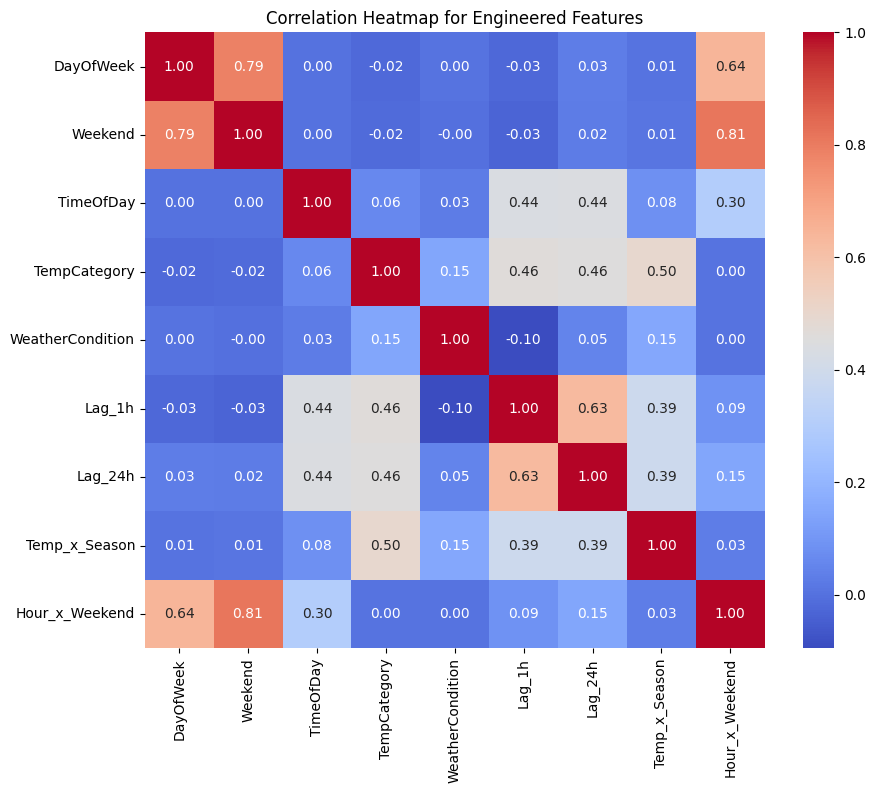

In [195]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Plot heatmap ----
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap for Engineered Features")
plt.show()


After analyzing the correlation matrix of the engineered features, I decided to focus on only four key features to reduce complexity and improve model efficiency. The first variable is Lag_1h, which represents the number of bikes rented in the previous hour, as it showed a strong correlation with consumption patterns and serves as a direct indicator of current demand. TempCategory is the thermal classification, providing important information about the weather’s impact on bike usage, while TimeOfDay reflects daily variations in bike demand during different periods of the day. Finally, the Temp_x_Season variable was retained as an interaction feature between temperature and season, as it may capture nonlinear joint effects between season and weather that neither variable alone can express. The selection of these four variables was based on the correlation matrix results, as they provide distinctive and complementary information without significant overlap, making them the most suitable for building an accurate predictive model.

In [196]:
# ---- List of Selected Features ----
selected_features = ['Lag_1h', 'TempCategory', 'TimeOfDay', 'Temp_x_Season']
target_col = 'Rented Bike Count'  # Correct name as in df.columns

# ---- 1. Check for Missing Values ----
print("----- Missing Values in Selected Features -----")
print(df[selected_features + [target_col]].isnull().sum())

# ---- 2. Check Data Types of Columns ----
print("\n----- Data Types of Selected Features -----")
print(df[selected_features + [target_col]].dtypes)

# ---- 3. Check Basic Statistics ----
print("\n----- Basic Statistics -----")
print(df[selected_features + [target_col]].describe())

# ---- 4. Check Correlation Between Selected Features ----
print("\n----- Correlation Matrix -----")
print(df[selected_features + [target_col]].corr())


----- Missing Values in Selected Features -----
Lag_1h               0
TempCategory         0
TimeOfDay            0
Temp_x_Season        0
Rented Bike Count    0
dtype: int64

----- Data Types of Selected Features -----
Lag_1h               float64
TempCategory            int8
TimeOfDay               int8
Temp_x_Season        float64
Rented Bike Count      int64
dtype: object

----- Basic Statistics -----
            Lag_1h  TempCategory    TimeOfDay  Temp_x_Season  \
count  8760.000000   8760.000000  8760.000000    8760.000000   
mean    704.564384      2.148174     1.500000      14.809874   
std     645.014149      1.572021     1.118098      25.489636   
min       0.000000      0.000000     0.000000     -53.400000   
25%     191.000000      1.000000     0.750000       0.000000   
50%     504.000000      3.000000     1.500000       7.350000   
75%    1065.250000      4.000000     2.250000      35.400000   
max    3556.000000      4.000000     3.000000      78.800000   

       Rented

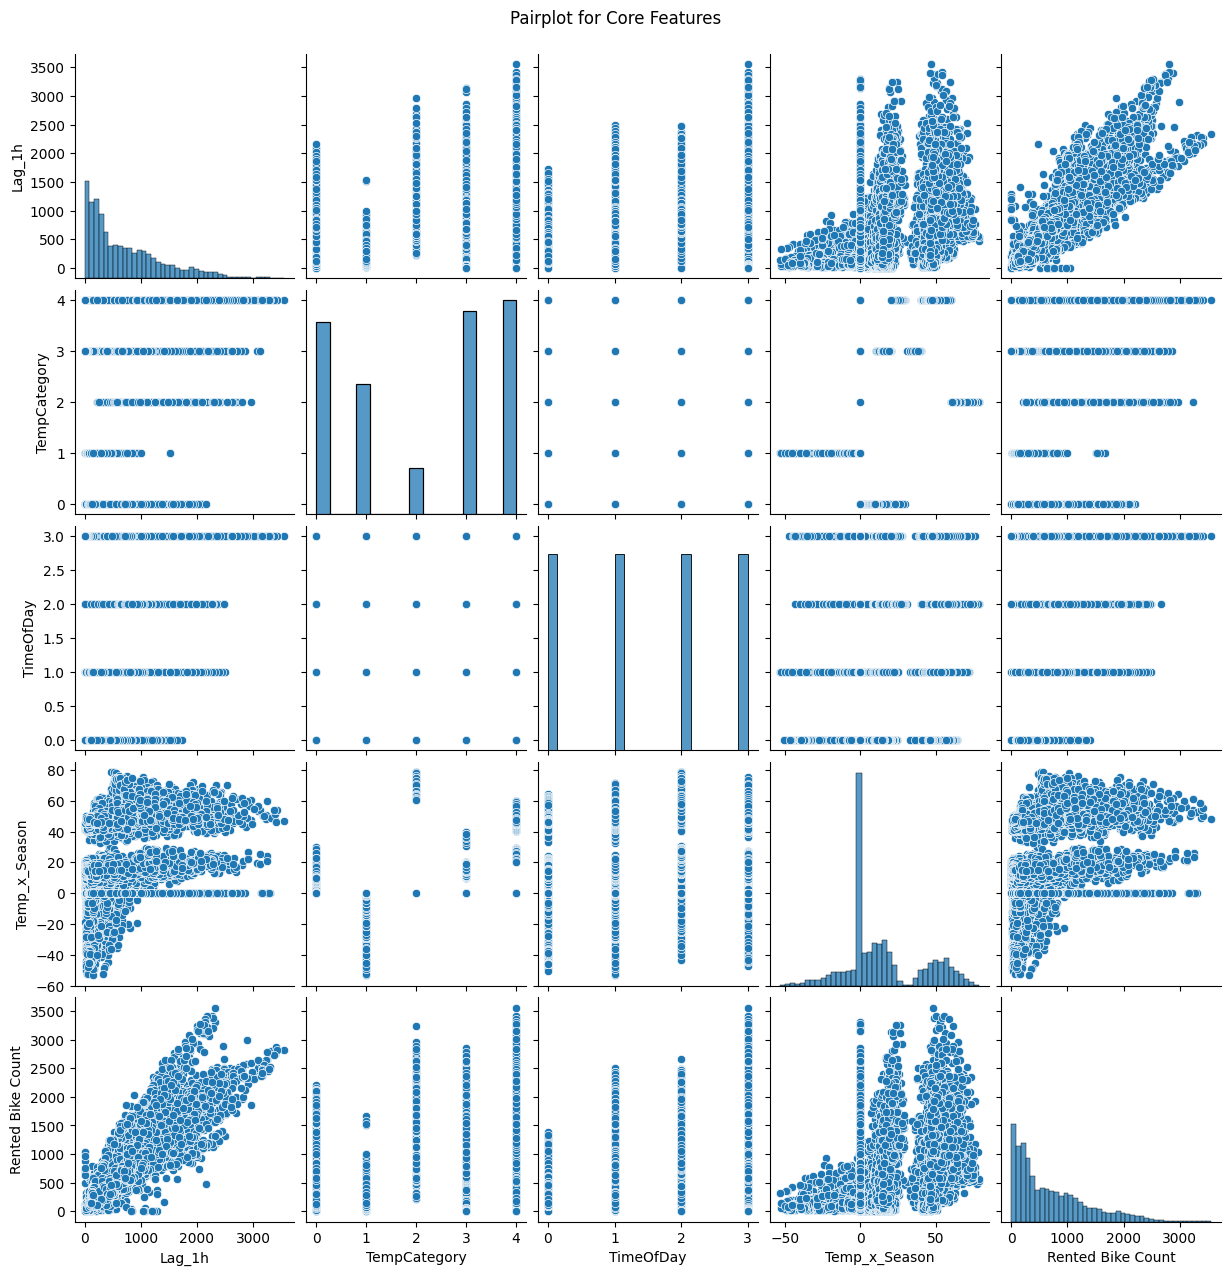

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[selected_features + ["Rented Bike Count"]])
plt.suptitle("Pairplot for Core Features", y=1.02)
plt.show()


After checking for missing values, data types, basic statistics, as well as analyzing the correlation between the selected features and the target variable, it was found that all four variables (**Lag\_1h, TempCategory, TimeOfDay, Temp\_x\_Season**) are perfectly suitable for the model. There are no issues that need fixing, so I can now confidently proceed to build the model.


In [202]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Define target and features
y = df["Rented Bike Count"]
X = df[
    [
        "Lag_1h",
        "TempCategory",
        "TimeOfDay",
        "Temp_x_Season"
    ]
]

# 2. Classify columns
categorical_features = ["TempCategory", "TimeOfDay"]
numeric_features = ["Lag_1h", "Temp_x_Season"]

# 3. ColumnTransformer for data preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# 4. Split data into Train/Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(" Data prepared based on selected key features!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


 Data prepared based on selected key features!
X_train shape: (7008, 4)
X_test shape: (1752, 4)


Initially, the most relevant columns for predicting the number of rented bikes are selected as the independent variables, including lagged rental counts from the previous hour and previous day (Lag_1h and Lag_24h), Hour_x_Weekend interaction, and other numerical features like Temperature, Dew point temperature, and Solar Radiation. The Rented Bike Count column serves as the target variable. Categorical columns in the independent variables, such as Seasons, Holiday, and Weekend, are converted into numerical format using One-Hot Encoding with drop="first" to avoid redundancy. Finally, the data is prepared for training and testing using the original values of the target variable, suitable for both linear models like Linear Regression and tree-based models like Random Forest Regression.

----- VIF for each feature -----
   feature       VIF
0        0  1.526492
1        1  2.502990
2        2  1.781778
3        3  3.852212
4        4  1.513564
5        5  1.670569
6        6  2.155138
7        7  3.906685
8        8  4.394237


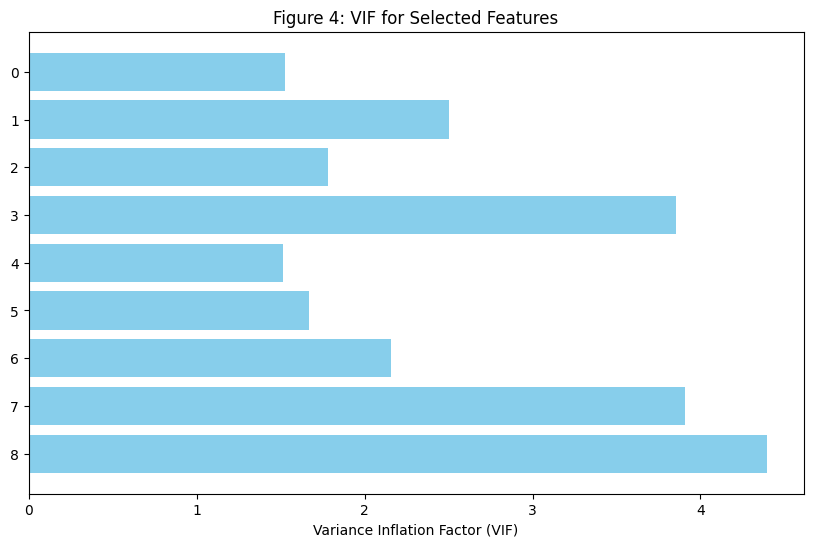


Linear Regression Model trained successfully!
MSE: 71604.9007624788
R² score: 0.828139811951004


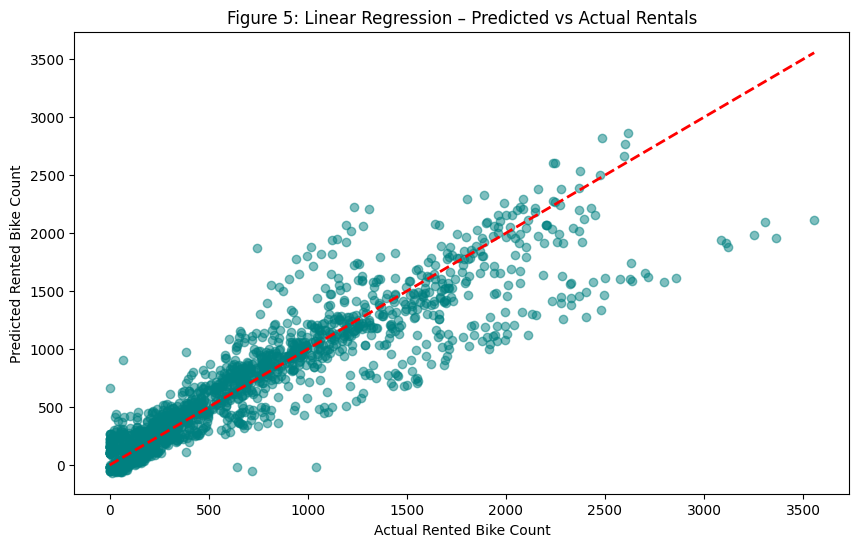

In [203]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# ---- 1. Define target and features ----
y = df["Rented Bike Count"]
X = df[["Lag_1h", "TempCategory", "TimeOfDay", "Temp_x_Season"]]

# ---- 2. Classify columns ----
categorical_features = ["TempCategory", "TimeOfDay"]
numeric_features = ["Lag_1h", "Temp_x_Season"]

# ---- 3. ColumnTransformer for data preprocessing ----
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# ---- 4. Split data into Train/Test sets ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- 5. Transform the data ----
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# ---- 6. Compute VIF ----
X_vif = pd.DataFrame(
    X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed
)
vif_data = pd.DataFrame()
vif_data["feature"] = range(X_vif.shape[1])
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("----- VIF for each feature -----")
print(vif_data)

# ---- 6a. Plot VIF ----
plt.figure(figsize=(10,6))
plt.barh(vif_data["feature"].astype(str), vif_data["VIF"], color='skyblue')
plt.xlabel("Variance Inflation Factor (VIF)")
plt.title("Figure 4: VIF for Selected Features")
plt.gca().invert_yaxis()
plt.show()

# ---- 7. Build Linear Regression ----
lr_model = LinearRegression()
lr_model.fit(X_train_transformed, y_train)

# ---- 8. Predict and evaluate ----
y_pred = lr_model.predict(X_test_transformed)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nLinear Regression Model trained successfully!")
print("MSE:", mse)
print("R² score:", r2)

# ---- 8a. Plot Figure 5: Linear Regression – predicted vs actual rentals ----
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Figure 5: Linear Regression – Predicted vs Actual Rentals")
plt.show()


After analyzing the correlation matrix of the variables, I decided to focus on four key features: **Lag\_1h, TempCategory, TimeOfDay, and Temp\_x\_Season**, as they provide strong and complementary information about bike demand without significant overlap. Missing values and data types were checked, and all were suitable for use. To avoid interpreting categorical variables as continuous values, **One-Hot Encoding** was applied to **TempCategory** and **TimeOfDay** before splitting the data into training and testing sets. Then, a **Linear Regression** model was trained on the transformed data.

The model results were strong, achieving **R² ≈ 0.83**, meaning the model explains approximately 83% of the variance in bike rentals, and **MSE ≈ 71,605**, indicating an acceptable average error given the range of values. The **VIF analysis** showed that all variables do not suffer from multicollinearity, making them valid for use in the model. Overall, these results indicate that the model is accurate and reliable for predicting the number of rented bikes based on these selected features.


Random Forest Model trained successfully!
MSE: 53736.638151102874
R² score: 0.8710257448941447

Feature Importances:
               Feature  Importance
7          num__Lag_1h    0.890526
8   num__Temp_x_Season    0.049135
4     cat__TimeOfDay_1    0.028458
5     cat__TimeOfDay_2    0.013082
3  cat__TempCategory_4    0.007240
2  cat__TempCategory_3    0.004884
6     cat__TimeOfDay_3    0.004674
0  cat__TempCategory_1    0.001407
1  cat__TempCategory_2    0.000594


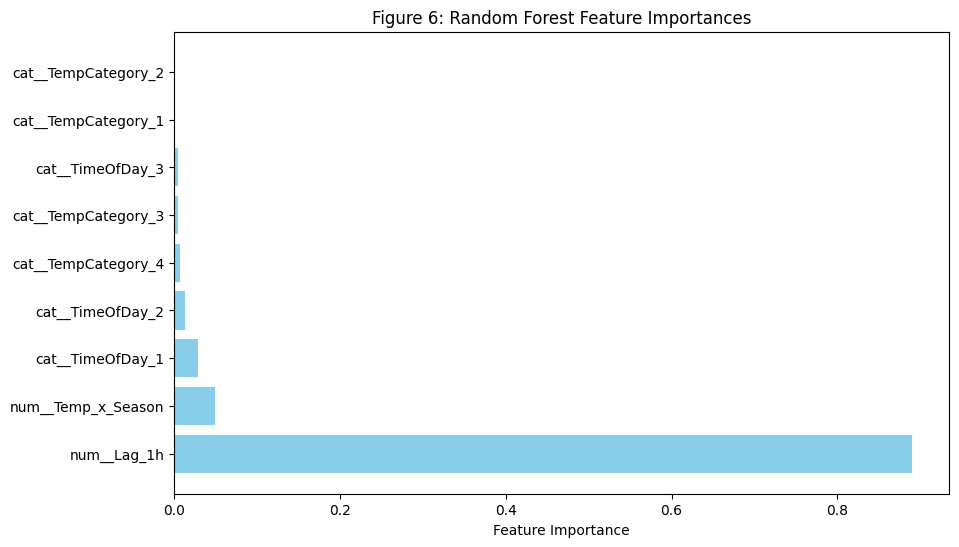

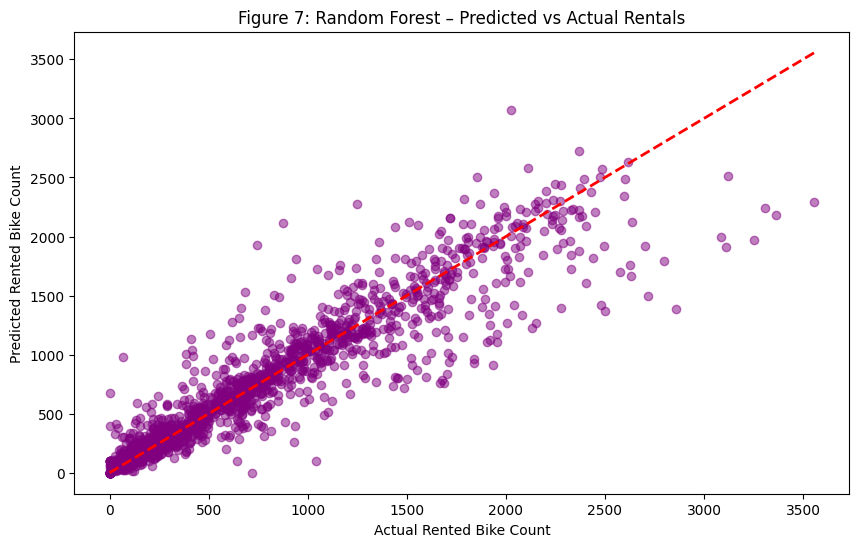

In [204]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. Define target and features ----
y = df["Rented Bike Count"]
X = df[["Lag_1h", "TempCategory", "TimeOfDay", "Temp_x_Season"]]

# ---- 2. Transform categorical variables ----
categorical_features = ["TempCategory", "TimeOfDay"]
numeric_features = ["Lag_1h", "Temp_x_Season"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# ---- 3. Split data into Train/Test sets ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- 4. Transform the data ----
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# ---- 5. Train Random Forest model ----
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_transformed, y_train)

# ---- 6. Predict and evaluate ----
y_pred = rf_model.predict(X_test_transformed)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest Model trained successfully!")
print("MSE:", mse)
print("R² score:", r2)

# ---- 7. Feature Importances ----
feature_names = preprocessor.get_feature_names_out()
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importances:")
print(importances)

# ---- 7a. Figure 6: Random Forest Feature Importances ----
plt.figure(figsize=(10,6))
plt.barh(importances["Feature"], importances["Importance"], color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Figure 6: Random Forest Feature Importances")
plt.show()

# ---- 7b. Figure 7: Random Forest – predicted vs actual rentals ----
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Figure 7: Random Forest – Predicted vs Actual Rentals")
plt.show()



A **Random Forest Regressor** model was trained to predict the number of rented bikes using the four key features: **"Lag\_1h", "TempCategory", "TimeOfDay", and "Temp\_x\_Season"**. The model showed strong performance with **MSE = 53,736.64** and **R² = 0.871**, indicating that it explains approximately 87% of the variance in bike rentals.

Feature importance analysis revealed that **"Lag\_1h"** is by far the most influential variable, contributing roughly 89% to the model’s decision, followed by **"Temp\_x\_Season"** at about 4.9%, while the categorical variables **"TimeOfDay"** and **"TempCategory"** have much smaller effects. This indicates that bike rentals are primarily driven by previous demand and the interaction between temperature and season, with limited influence from the time of day and thermal category.


Gradient Boosting Model trained successfully!
MSE: 52978.16833628834
R² score: 0.8728461617038251

Feature Importances:
          Feature  Importance
7          Lag_1h    0.935056
4     TimeOfDay_1    0.034017
5     TimeOfDay_2    0.013167
8   Temp_x_Season    0.011260
3  TempCategory_4    0.003257
6     TimeOfDay_3    0.002322
1  TempCategory_2    0.000476
2  TempCategory_3    0.000281
0  TempCategory_1    0.000164


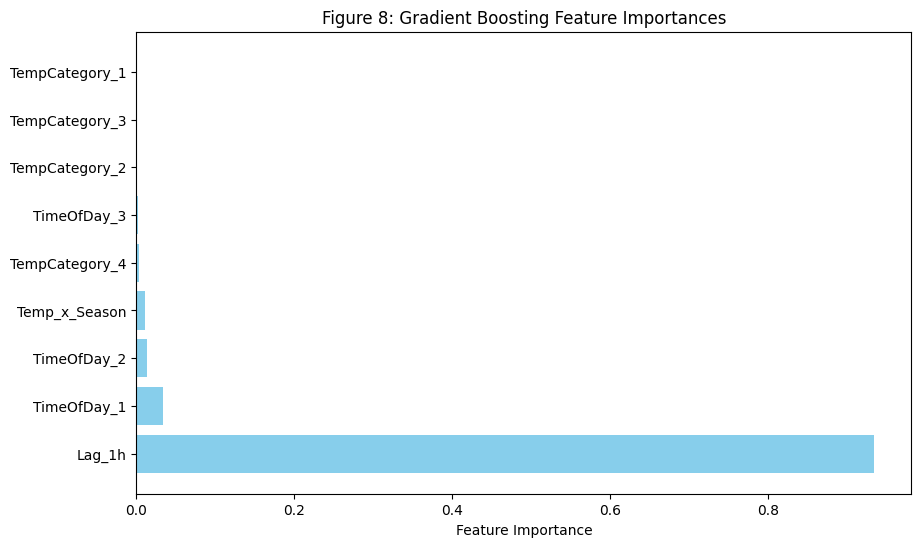

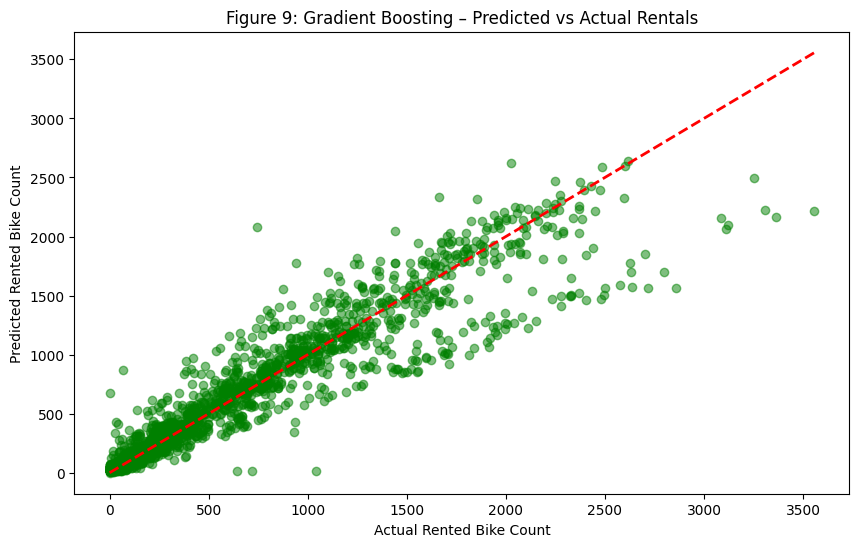

In [205]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. Transform the data ----
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# ---- 2. Build Gradient Boosting model ----
gb_model = GradientBoostingRegressor(
    n_estimators=200,   # Number of trees
    learning_rate=0.1,  # Learning rate
    max_depth=3,        # Maximum depth of each tree
    random_state=42
)

# ---- 3. Train the model ----
gb_model.fit(X_train_transformed, y_train)

# ---- 4. Predict and evaluate ----
y_pred = gb_model.predict(X_test_transformed)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Gradient Boosting Model trained successfully!")
print("MSE:", mse)
print("R² score:", r2)

# ---- 5. Feature Importances ----
feature_names = (
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features).tolist()
    + numeric_features
)
feature_importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importances:")
print(feature_importances)

# ---- Figure 8: Gradient Boosting Feature Importances ----
plt.figure(figsize=(10,6))
plt.barh(feature_importances["Feature"], feature_importances["Importance"], color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Figure 8: Gradient Boosting Feature Importances")
plt.show()

# ---- Figure 9: Gradient Boosting – predicted vs actual rentals ----
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Figure 9: Gradient Boosting – Predicted vs Actual Rentals")
plt.show()


The **Gradient Boosting** results show that the model can predict the number of rented bikes with high accuracy, as indicated by **R² = 0.873**, reflecting a strong alignment between predicted and actual values, and a low **MSE**, indicating small prediction errors.

In terms of feature importance, **Lag\_1h** emerges as the critical factor, while other variables such as **TimeOfDay** and **Temp\_x\_Season** play secondary roles, and categorical variables like **TempCategory** have very minimal impact. This suggests that past temporal trends have a stronger influence on bike rentals compared to climatic or categorical factors.


In the analysis of bike rental predictions using the features **Lag\_1h, TempCategory, TimeOfDay, and Temp\_x\_Season**, the three models showed varying results that reflect the strengths and flexibility of each algorithm.

**Linear Regression:**
The linear model showed acceptable performance, with **R² = 0.828** and **MSE = 71,604.9**.
VIF analysis indicated that multicollinearity among features was not concerning, meaning the model could handle feature variance without major issues.
However, the linear assumption limits the model’s ability to capture nonlinear patterns or complex interactions between features, particularly the strong temporal effect of **Lag\_1h**.

**Random Forest:**
The nonlinear model showed a significant performance improvement with **R² = 0.871** and **MSE = 53,736.6**, indicating more accurate predictions.
Feature importance analysis revealed that **Lag\_1h** is clearly the most influential variable, while the other categorical and temporal features have limited impact.
The model can capture nonlinear interactions between features, giving it an advantage over linear regression, especially with strong temporal patterns.

**Gradient Boosting:**
This sequential model showed the best performance with **R² = 0.873** and **MSE = 52,978.2**, slightly outperforming Random Forest.
Feature importance emphasized an even greater reliance on **Lag\_1h** (\~93.5%), reflecting its heavy dependence on previous temporal trends for predictions.
The model improves errors step by step (boosting), making it more precise in capturing small patterns and fluctuations in the data compared to the random forest.

**General Conclusion:**
All models confirmed that **Lag\_1h** is the most influential factor, highlighting that past temporal trends are key for predicting bike rentals.
Nonlinear models (Random Forest and Gradient Boosting) outperformed Linear Regression, indicating that the relationship between features and the target is not purely linear.
Gradient Boosting provided slightly better precision than Random Forest while emphasizing the critical role of temporal variables.

**Summary:**
For high predictive accuracy and handling nonlinear interactions, **Gradient Boosting** is the optimal choice. Linear Regression is useful for interpreting direct feature effects but is less capable of capturing complex patterns.
